In [1]:
import os
import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from rapidfuzz import fuzz, process
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import SparsePCA
from sklearn.model_selection import train_test_split

from scholarlm.utils import get_filenames_in_directory, get_foldernames_in_directory, correct_image_orientation, tokenize
from dotenv import load_dotenv
load_dotenv()

INFO 12-17 10:33:27 [__init__.py:220] No platform detected, vLLM is running on UnspecifiedPlatform
WARNING 12-17 10:33:31 [_custom_ops.py:20] Failed to import from vllm._C with ImportError('libcuda.so.1: cannot open shared object file: No such file or directory')


True

### Load Data

In [2]:
main_directory = os.getenv("POND_PATH")
data_directory = os.getenv("POND_DATA_PATH")
pdf_directory = os.getenv("POND_PDF_PATH")
text_directory = os.getenv("POND_TEXT_PATH")
image_directory = os.getenv("POND_IMAGE_PATH")

In [3]:
# Directory
with open(os.path.join(main_directory, "directory.json"), "r") as f:
    paper_info = json.load(f)


paper_subset = [
    'physical_and_chemical_limnological',
    'physical-chemical_influences',
    'prairie_wetland',
    'net_heterotrophy',
    'habitat_characteristics',
    'biodiversity_of_constructed',
    'fish_production_in_lakes',
    'long-term_stability',
    'diversity_of_macroinvertebrates',
    'impact_of_macrophytes'
]

paper_info = {k:v for k,v in paper_info.items() if k in paper_subset}


registered_titles = [entry['title'] for entry in paper_info.values()]
registered_titles.sort()
#registered_titles = [registered_titles[i] for i in finished_papers]

# Original dataset
pond_data = pd.read_csv(os.path.join(data_directory, "pond_data.csv"), encoding_errors='ignore')
pond_data = pond_data.loc[pond_data.title.isin(registered_titles)]
pond_df = pond_data.loc[:,['author', 'title', 'pondname', 'location', 'author_term',
            'max_depth_m', 'mean_surfacearea_m2', 'macrophytes_percentcover', 'ph', 'tn_ugpl', 'tp_ugpl', 'chla_ugpl']]
pond_df.columns = ['author', 'title', 'name', 'location', 'ecosystem',
            'max_depth', 'surface_area', 'vegetation_cover', 'ph', 'tn', 'tp', 'chla']

# Split the dataframe's rows so that each measurement is in its own row
pond_df = pond_df.melt(id_vars=['author', 'title', 'name', 'location', 'ecosystem'], 
                       value_vars=['max_depth', 'surface_area', 'vegetation_cover', 'ph', 'tn', 'tp', 'chla'],
                       var_name='measurement', value_name='value')
pond_df = pond_df.dropna(subset=['value'])
pond_df = pond_df.reset_index(drop=True)
n_entries = pond_df.shape[0]

In [4]:
def process(
    result_df,
    conversion_table
):
    result_df = result_df.copy()

    # Drop rows without any measurements
    result_df = result_df.dropna(subset=['value'])
    result_df = result_df.reset_index(drop=True)

    # Convert units
    processed_values = [val for val in result_df.loc[:,'value']]
    for row_idx, row in result_df.iterrows():
        measurement_type = row['measurement']
        val = row['value']
        unit = row['units']
        if conversion_table.get(measurement_type) is not None:
            if conversion_table[measurement_type].get(unit) is not None:
                conversion_factor = conversion_table[measurement_type][unit]
                processed_values[row_idx] = val * conversion_factor


    result_df['processed_value'] = processed_values
    result_df = result_df.dropna(subset=['processed_value'])
    result_df = result_df.reset_index(drop=True)

    # Drop all unit columns
    #result_df = result_df.drop(columns=["units"])

    # Drop exact duplicates
    result_df = result_df.drop_duplicates()

    # Reset index
    result_df = result_df.reset_index(drop=True)

    return result_df


conversion_table = {
    'max_depth': {"cm": 0.01, "feet": 0.3048, "km": 1000, "m": 1},
    'surface_area': {"km^2": 1e6, "ha": 1e4, "mi^2": 2.59e6, "m^2": 1},
    'vegetation_cover': {"percent": 0.01, "fraction": 1},
    'tn': {"mg/L": 1000, "µg/L": 1, "μmol/L": 14.01, "ppm": 1000, "ppb": 1},
    'tp': {"mg/L": 1000, "µg/L": 1, "μmol/L": 30.97, "ppm": 1000, "ppb": 1},
    'chla': {"mg/L": 1000, "µg/L": 1},
    'ph': {},
    'latitude': {},
    'longitude': {}
}

In [5]:
with open("../data/12_17_25/ten_judged.json", "r") as f:
    result_dict = json.load(f)

scores = ['context_scores', 'parametric_scores', 'copying_scores', 'linear_probes', 'measurement_names', 'entity_names', 'row_index', 'column_index']
result_dict = [{k:v for k,v in entry.items() if k not in scores} for entry in result_dict]
result_df = pd.DataFrame(result_dict)

In [6]:
result_df = result_df.loc[result_df.title.isin(registered_titles)]
result_df = result_df.reset_index(drop=True)

ignore_measurements = ['latitude', 'longitude'] # Ignoring these for now because they are not in the original dataset

result_df = result_df.loc[~result_df.measurement.isin(ignore_measurements)]
result_df['value'] = result_df['value'].str.replace(',', '')  # Remove commas from numbers
result_df['value'] = pd.to_numeric(result_df['value'], errors='coerce')
result_df = process(result_df, conversion_table)
result_df.sort_values(by=["title"], inplace=True)
result_df = result_df.reset_index(drop=True)

In [12]:
result_df.name.value_counts()

name
Toderian               14
Tenr                    9
Vbk1                    9
WtM1                    9
MlGr                    9
                       ..
Slotsø                  1
Muskoka (CWS) lakes     1
Dorset lakes            1
Hwy Z Kettle            1
HS2-1                   1
Name: count, Length: 157, dtype: int64

In [15]:
result_df.loc[result_df.name=='Tenr']

,title,author,year,paper_code,document_id,context,name,date,location,ecosystem,page_number,measurement,measurement_id,table_number,value,units,judgement,processed_value
22,impact of macrophytes on phytoplankton in eutr...,peretyatko,2007,impact_of_macrophytes,9,"<page number=""0"">\n\nIMPACT OF MACROPHYTES ON ...",Tenr,2002-05-01,Woluwe River catchment,pond,4,chla,22579,0,3.10,µg/L,valid,3.1
23,impact of macrophytes on phytoplankton in eutr...,peretyatko,2007,impact_of_macrophytes,9,"<page number=""0"">\n\nIMPACT OF MACROPHYTES ON ...",Tenr,2002-05-01,Woluwe River catchment,pond,4,tp,22578,0,0.24,mg/L,valid,240.0
24,impact of macrophytes on phytoplankton in eutr...,peretyatko,2007,impact_of_macrophytes,9,"<page number=""0"">\n\nIMPACT OF MACROPHYTES ON ...",Tenr,2002-05-01,Woluwe River catchment,pond,4,ph,22576,0,7.90,NaN,valid,7.9
40,impact of macrophytes on phytoplankton in eutr...,peretyatko,2007,impact_of_macrophytes,9,"<page number=""0"">\n\nIMPACT OF MACROPHYTES ON ...",Tenr,2005-05-01,Woluwe River catchment,pond,4,ph,25096,0,7.90,NaN,valid,7.9
41,impact of macrophytes on phytoplankton in eutr...,peretyatko,2007,impact_of_macrophytes,9,"<page number=""0"">\n\nIMPACT OF MACROPHYTES ON ...",Tenr,2005-05-01,Woluwe River catchment,pond,4,tp,25098,0,0.24,mg/L,valid,240.0
49,impact of macrophytes on phytoplankton in eutr...,peretyatko,2007,impact_of_macrophytes,9,"<page number=""0"">\n\nIMPACT OF MACROPHYTES ON ...",Tenr,2005-05-01,Woluwe River catchment,pond,4,chla,25099,0,3.10,µg/L,valid,3.1
57,impact of macrophytes on phytoplankton in eutr...,peretyatko,2007,impact_of_macrophytes,9,"<page number=""0"">\n\nIMPACT OF MACROPHYTES ON ...",Tenr,2004-05-01,Woluwe River catchment,pond,4,ph,23836,0,7.90,NaN,valid,7.9
58,impact of macrophytes on phytoplankton in eutr...,peretyatko,2007,impact_of_macrophytes,9,"<page number=""0"">\n\nIMPACT OF MACROPHYTES ON ...",Tenr,2004-05-01,Woluwe River catchment,pond,4,tp,23838,0,0.24,mg/L,valid,240.0
59,impact of macrophytes on phytoplankton in eutr...,peretyatko,2007,impact_of_macrophytes,9,"<page number=""0"">\n\nIMPACT OF MACROPHYTES ON ...",Tenr,2004-05-01,Woluwe River catchment,pond,4,chla,23839,0,3.10,µg/L,valid,3.1


### Match with ground truth

In [8]:
def match_datapoints(ground_truth, extracted):
    edges = []
    edge_weights = []
    for i, row_gt in ground_truth.iterrows():
        for j, row_ex in extracted.iterrows():
            if (
                row_gt['title'] == row_ex['title'] and 
                row_gt['measurement'] == row_ex['measurement'] and 
                np.isclose(row_gt['value'], row_ex['processed_value'], atol=1e-3)
            ):
                name_similarity = fuzz.ratio(row_gt['name'], row_ex['name']) / 100.0
                location_similarity = fuzz.ratio(row_gt['location'], row_ex['location']) / 100.0
                ecosystem_similarity = fuzz.ratio(row_gt['ecosystem'], row_ex['ecosystem']) / 100.0
                weight = (name_similarity + location_similarity + ecosystem_similarity) / 3.0
                edges.append((i, j))
                edge_weights.append(weight)

    print(f"Total edges found: {len(edges)}")
    # Create a bipartite graph and find maximum weight matching
    G = nx.Graph()
    G.add_edges_from([(f"gt_{i}", f"ex_{j}", {'weight': w}) for (i, j), w in zip(edges, edge_weights)])
    matching = nx.algorithms.matching.max_weight_matching(G)
    index_matching = []
    for i, j in matching:
        if i.startswith("gt_"):
            index_matching.append((int(i[3:]), int(j[3:])))
        else:
            index_matching.append((int(j[3:]), int(i[3:])))
    
    return index_matching


def estimate_precision_recall(ground_truth, extracted):
    total_ground_truth = ground_truth.shape[0]
    total_extracted = extracted.shape[0]

    matching = match_datapoints(ground_truth, extracted)

    true_positives = len(matching)
    precision = true_positives / total_extracted if total_extracted > 0 else 0
    recall = true_positives / total_ground_truth if total_ground_truth > 0 else 0

    return recall, precision

In [9]:
matching = match_datapoints(pond_df, result_df)

Total edges found: 1021


In [11]:
len(matching)

354

In [70]:
1045 - 354

691

In [17]:
gt_matched = np.array([False] * pond_df.shape[0])
ex_matched = np.array([False] * result_df.shape[0])
for gt_idx, ex_idx in matching:
    gt_matched[gt_idx] = True
    ex_matched[ex_idx] = True

unmatched_gt = np.where(~gt_matched)[0]
unmatched_ex = np.where(~ex_matched)[0]

unmatched_gt_df = pond_df[gt_matched == False]
unmatched_gt_titles = unmatched_gt_df.title.value_counts().index

matched_ex_df = result_df[ex_matched == True]
unmatched_ex_df = result_df[ex_matched == False]
unmatched_ex_titles = unmatched_ex_df.title.value_counts().index

In [61]:
matched_ex_df.loc[matched_ex_df.name == "BZ"]

,title,author,year,paper_code,document_id,context,name,date,location,ecosystem,page_number,measurement,measurement_id,table_number,value,units,judgement,processed_value
323,physical and chemical limnological characteris...,lim et al.,2001,physical_and_chemical_limnological,0,"<page number=""0"">\n\n1Darlene S. S. Lim, 1Mari...",BZ,1994-07-14,"75°43.25 N, 98°40.68 W",lake,6,tn,3588,2,641.9,µg/L,valid,641.9
340,physical and chemical limnological characteris...,lim et al.,2001,physical_and_chemical_limnological,0,"<page number=""0"">\n\n1Darlene S. S. Lim, 1Mari...",BZ,1994-07-14,"75°43.25 N, 98°40.68 W",lake,6,ph,3587,2,8.2,NaN,valid,8.2
355,physical and chemical limnological characteris...,lim et al.,2001,physical_and_chemical_limnological,0,"<page number=""0"">\n\n1Darlene S. S. Lim, 1Mari...",BZ,1994-07-14,"75°43.25 N, 98°40.68 W",lake,5,tp,3582,1,45.4,µg/L,valid,45.4


In [20]:
unmatched_gt_df.title.value_counts()

title
habitat characteristics and odonate diversity in mountain ponds of central italy                                              155
prairie wetland communities recover at different rates following hydrological restoration                                     129
physical-chemical influences on vernal zooplankton community structure in small lakes and wetlands of wisconsin; usa           79
biodiversity of constructed wetlands for wastewater treatment                                                                  78
impact of macrophytes on phytoplankton in eutrophic peri-urban ponds; implications for pond management and restoration         68
diversity of macroinvertebrates positively correlates with diversity of macrophytes in karst ponds                             64
fish production in lakes as a guide for estimating production in proposed reservoirs                                           56
physical and chemical limnological characteristics of 38 lakes and ponds on bathurst

In [24]:
unmatched_ex_df.loc[unmatched_ex_df.document_id == 4]

,title,author,year,paper_code,document_id,context,name,date,location,ecosystem,page_number,measurement,measurement_id,table_number,value,units,judgement,processed_value


In [25]:
result_df.loc[result_df.document_id == 4]

,title,author,year,paper_code,document_id,context,name,date,location,ecosystem,page_number,measurement,measurement_id,table_number,value,units,judgement,processed_value


In [72]:
unmatched_ex_df.judgement.value_counts()

judgement
hallucination     136
valid             126
disorientation     27
Name: count, dtype: int64

### Manually validated results

In [72]:
with open("../data/12_11_25/pond_validated.json", "r") as f:
    validated_dict = json.load(f)

validated_df = pd.DataFrame(validated_dict)
#validated_df = validated_df.loc[validated_df.validation_status == "deviation"]

measure_ids = [mid for mid in validated_df.measurement_id if (mid in result_df.measurement_id.to_list()) and (mid != 924)]
judgement_df = result_df.loc[result_df.measurement_id.isin(measure_ids)]
judgement_df = judgement_df.sort_values(by = "measurement_id")
validated_df = validated_df.loc[validated_df.measurement_id.isin(measure_ids)]
validated_df = validated_df.sort_values(by = "measurement_id")

'''
matched_ex_df['validation_status'] = 'valid'
matched_ex_df['unit_status'] = True
matched_ex_df['ocr_status'] = True

validated_df = pd.concat([matched_ex_df.sample(n = 900, random_state = 42), validated_df], ignore_index=True)

# Shuffle the validated dataframe
validated_df = validated_df.sample(frac=1, random_state=42).reset_index(drop=True)
'''

"\nmatched_ex_df['validation_status'] = 'valid'\nmatched_ex_df['unit_status'] = True\nmatched_ex_df['ocr_status'] = True\n\nvalidated_df = pd.concat([matched_ex_df.sample(n = 900, random_state = 42), validated_df], ignore_index=True)\n\n# Shuffle the validated dataframe\nvalidated_df = validated_df.sample(frac=1, random_state=42).reset_index(drop=True)\n"

In [75]:
validated_df

,title,author,year,paper_code,document_id,context,name,date,location,ecosystem,measurement_id,measurement,page_id,value,unit_status,ocr_status,validation_status,units
1,bacterial processes and biogeochemical changes...,attermeyer; katrin; grossart; hans-peter; flur...,2017,bacterial_processes,5,<PAGE_0>\n\nBacterial processes and biogeochem...,Kettle Hole 6,2014-06-24,"53.416N 13.666E, north-eastern Germany",kettle hole,4468,surface_area,1,0.129,False,True,valid,km^2
21,daphnia diversity in water bodies of the po ri...,markova et al.,2017,daphnia_diversity,21,<PAGE_0>\n\nDaphnia diversity in water bodies ...,Bosco Braca pond,2014,Po River Basin,pond,4719,surface_area,2,2460,True,True,valid,m^2
22,daphnia diversity in water bodies of the po ri...,markova et al.,2017,daphnia_diversity,21,<PAGE_0>\n\nDaphnia diversity in water bodies ...,Motta pond,2014,Po River Basin,pond,4732,surface_area,2,2230,True,True,valid,m^2
24,diel vertical migrations of zooplankton in a s...,gilbert & hampton,2001,diel_vertical_migrations,23,<PAGE_0>\n\nDiel vertical migrations of zoopla...,Johnson Pond,1998-07-01,"Norwich, Vermont, U.S.A.",pond,4759,surface_area,2,0.1,False,True,valid,km^2
25,distinct optical chemistry of dissolved organi...,mcenroe et al,2013,distinct_optical,25,<PAGE_0>\n\nDistinct Optical Chemistry of Diss...,19-4,2009-06,"Richmond Hill, Canada",pond,4787,surface_area,1,2098,True,True,disorientation,m^2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,net heterotrophy in small danish lakes: a wide...,sand-jensen,2009,net_heterotrophy,67,<PAGE_0>\n\nNet Heterotrophy in Small Danish L...,Fønstrup dam,2001-11-01,"North Zealand, Denmark",lake,18643,chla,2,19.6,True,True,valid,µg/L
72,physical and chemical limnological characteris...,lim et al.,2001,physical_and_chemical_limnological,74,"<PAGE_0>\n\n1Darlene S. S. Lim, 1Marianne S. V...",BAG,1994-07-14,"76°23.18 N, 98°52.05 W",pond,18824,chla,17,1.7,True,True,valid,µg/L
75,production of fish populations in lakes,downing and plante,1993,production_of_fish,80,<PAGE_0>\n\nProduction of Fish Populations in ...,Kiutajärvi,None,None,lake,18920,chla,4,10,True,True,disorientation,µg/L
87,strength of phytoplankton-nutrient relationshi...,teissier; samuel; peretyatko; anatoly; de back...,2012,strength_of_phytoplankton,103,<PAGE_0>\n\nStrength of phytoplankton–nutrient...,Pond Beml,2006,Brussels Capital Region (Belgium),pond,19369,chla,1,23.4,True,True,valid,µg/L


In [76]:
judgement_df

,title,author,year,paper_code,document_id,context,name,date,location,ecosystem,measurement_id,measurement,page_id,value,units,judgement,processed_value
246,bacterial processes and biogeochemical changes...,attermeyer; katrin; grossart; hans-peter; flur...,2017.0,bacterial_processes,5,<PAGE_0>\n\nBacterial processes and biogeochem...,Kettle Hole 6,2014-06-24,"53.416N 13.666E, north-eastern Germany",kettle hole,4468,surface_area,1,0.129,km^2,valid,129000.0
1102,daphnia diversity in water bodies of the po ri...,markova et al.,2017.0,daphnia_diversity,21,<PAGE_0>\n\nDaphnia diversity in water bodies ...,Bosco Braca pond,2014,Po River Basin,pond,4719,surface_area,2,2460.000,m^2,valid,2460.0
1123,daphnia diversity in water bodies of the po ri...,markova et al.,2017.0,daphnia_diversity,21,<PAGE_0>\n\nDaphnia diversity in water bodies ...,Motta pond,2014,Po River Basin,pond,4732,surface_area,2,2230.000,m^2,valid,2230.0
1252,diel vertical migrations of zooplankton in a s...,gilbert & hampton,2001.0,diel_vertical_migrations,23,<PAGE_0>\n\nDiel vertical migrations of zoopla...,Johnson Pond,1998-07-01,"Norwich, Vermont, U.S.A.",pond,4759,surface_area,2,0.100,km^2,disorientation,100000.0
1304,distinct optical chemistry of dissolved organi...,mcenroe et al,2013.0,distinct_optical,25,<PAGE_0>\n\nDistinct Optical Chemistry of Diss...,19-4,2009-06,"Richmond Hill, Canada",pond,4787,surface_area,1,2098.000,m^2,valid,2098.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3203,net heterotrophy in small danish lakes: a wide...,sand-jensen,2009.0,net_heterotrophy,67,<PAGE_0>\n\nNet Heterotrophy in Small Danish L...,Fønstrup dam,2001-11-01,"North Zealand, Denmark",lake,18643,chla,2,19.600,µg/L,valid,19.6
3497,physical and chemical limnological characteris...,lim et al.,2001.0,physical_and_chemical_limnological,74,"<PAGE_0>\n\n1Darlene S. S. Lim, 1Marianne S. V...",BAG,1994-07-14,"76°23.18 N, 98°52.05 W",pond,18824,chla,17,1.700,µg/L,valid,1.7
4194,production of fish populations in lakes,downing and plante,1993.0,production_of_fish,80,<PAGE_0>\n\nProduction of Fish Populations in ...,Kiutajärvi,None,None,lake,18920,chla,4,10.000,µg/L,deviation,10.0
5341,strength of phytoplankton-nutrient relationshi...,teissier; samuel; peretyatko; anatoly; de back...,2012.0,strength_of_phytoplankton,103,<PAGE_0>\n\nStrength of phytoplankton–nutrient...,Pond Beml,2006,Brussels Capital Region (Belgium),pond,19369,chla,1,23.400,µg/L,valid,23.4


### LLM as Judge Baseline

In [77]:
# Complete accuracy calculation
judge_array = judgement_df.judgement.to_numpy()
#judge_array = validated_df.judgement.to_numpy()
validation_array = validated_df.validation_status.to_numpy()
(judge_array == validation_array).sum() / len(validation_array)

0.5217391304347826

In [78]:
# Recall -- for each type
status_type = 'deviation'
select = np.where(validation_array == status_type)[0]
(judge_array[select] == validation_array[select]).sum() / len(select)

0.2

In [79]:
# Valid / Invalid false positive rate
select = np.where(validation_array != 'valid')[0]
(judge_array[select] == 'valid').sum() / len(select)

0.5416666666666666

In [81]:
judge_array[select]

array(['valid', 'valid', 'disorientation', 'valid', 'deviation', 'valid',
       'hallucination', 'valid', 'disorientation', 'valid', 'valid',
       'valid', 'valid', 'hallucination', 'deviation', 'deviation',
       'hallucination', 'valid', 'hallucination', 'valid',
       'hallucination', 'valid', 'valid', 'deviation'], dtype=object)

In [80]:
judgement_df.judgement.value_counts()

judgement
valid             59
hallucination     16
deviation          9
disorientation     8
Name: count, dtype: int64

### Interpretability Scores

In [70]:
# Load data:
linear_probes = []
hallucination_scores = []
copying_scores = []

for i, row in validated_df.iterrows():
    measurement_id = row['measurement_id']
    loaded_scores = np.load(f"../data/pond_page_chunks2/{measurement_id}.npz")

    # Take results from first generated token
    linear_probes.append(loaded_scores['linear_probes'][0])

    # Average scores over all generated tokens
    parametric_scores = loaded_scores['parametric_scores'].mean(axis=0)
    context_scores = loaded_scores['context_scores'].mean(axis=0).flatten()
    hallucination_scores.append(np.concatenate([parametric_scores, context_scores]))

    # Flatten copying scores
    copying_scores.append(loaded_scores['copying_scores'].flatten())

linear_probes = np.array(linear_probes)
hallucination_scores = np.array(hallucination_scores)
copying_scores = np.array(copying_scores)


##### Linear Probe

In [82]:
status_dict = {
    'valid': 1,
    'hallucination': 0,
    'disorientation': 0,
    'deviation': 0,
}

X = linear_probes
y = validated_df['validation_status'].map(status_dict)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [83]:
# Fitting regularization parameter for logistic regression
regularization_params = np.linspace(0.0, 0.1, 101)
scores = np.empty((len(regularization_params), 5))

for i, alpha in enumerate(regularization_params):
    model = LogisticRegression(C=1/(alpha + 1e-10), penalty = "l1", solver = "liblinear", max_iter=1000)
    cv_results = cross_validate(model, X, y, cv=5, scoring='accuracy')
    scores[i, :] = cv_results['test_score']

In [85]:
np.mean(scores, axis=1)

array([0.937, 0.938, 0.936, 0.936, 0.938, 0.934, 0.932, 0.935, 0.937,
       0.939, 0.937, 0.937, 0.938, 0.936, 0.939, 0.936, 0.937, 0.937,
       0.939, 0.936, 0.937, 0.939, 0.934, 0.935, 0.936, 0.934, 0.936,
       0.936, 0.935, 0.934, 0.936, 0.936, 0.936, 0.936, 0.935, 0.934,
       0.936, 0.939, 0.937, 0.932, 0.935, 0.935, 0.937, 0.934, 0.934,
       0.935, 0.934, 0.936, 0.933, 0.936, 0.936, 0.936, 0.936, 0.933,
       0.934, 0.937, 0.935, 0.937, 0.934, 0.936, 0.933, 0.935, 0.936,
       0.937, 0.935, 0.934, 0.936, 0.937, 0.936, 0.933, 0.936, 0.936,
       0.935, 0.935, 0.935, 0.934, 0.936, 0.935, 0.936, 0.938, 0.937,
       0.936, 0.935, 0.936, 0.936, 0.933, 0.935, 0.934, 0.935, 0.934,
       0.937, 0.935, 0.937, 0.931, 0.934, 0.937, 0.933, 0.932, 0.935,
       0.934, 0.933])

Text(0, 0.5, 'Reconstruction Error')

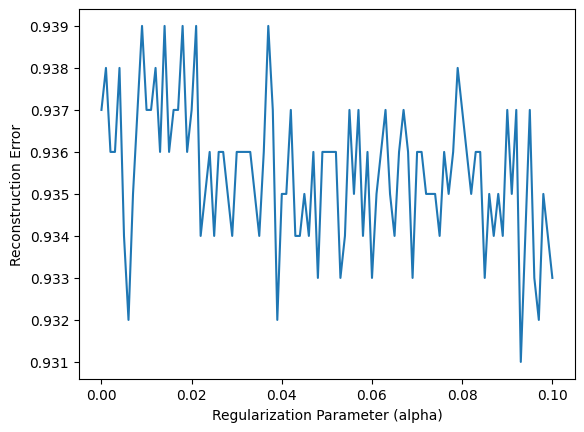

In [86]:
plt.plot(regularization_params, np.mean(scores, axis = 1))
plt.xlabel('Regularization Parameter (alpha)')
plt.ylabel('Reconstruction Error')

##### Hallucination Scores

In [88]:
status_dict = {
    'valid': 1,
    'hallucination': 0,
    'disorientation': 1,
    'deviation': 1,
}

X = hallucination_scores
y = validated_df['validation_status'].map(status_dict)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [89]:
X.shape

(1000, 1056)

In [ ]:
regularization_params[np.argmax(np.mean(scores, axis=1))]

In [ ]:
# Fit logistic regression model
alpha = 9e-05
model = LogisticRegression(C = 1/(alpha + 1e-10), penalty = "l1", solver='liblinear', max_iter=1000, random_state = 342)
model.fit(X, y)
#train_accuracy = model.score(X_train, y_train)
#print(f"Logistic Regression Train Accuracy: {train_accuracy:.4f}")
#accuracy = model.score(X, y)
#print(f"Logistic Regression Test Accuracy: {accuracy:.4f}")

coefficients = model.coef_[0]
context_coefficients = coefficients[:-32].reshape(32, 32)
parametric_coefficients = coefficients[-32:]

In [ ]:
model.predict(X_test)

In [ ]:
y_test

In [ ]:
pond_df

In [ ]:
fig,ax = plt.subplots(figsize=(6,6), dpi = 100)
pos = ax.matshow(context_coefficients, cmap='BuPu')
ax.set_ylabel('Layers')
ax.set_xlabel('Heads')
ax.set_title(f'Context Score Coefficients')
fig.colorbar(pos, ax=ax)

In [ ]:
fig,ax = plt.subplots(figsize=(6,4), dpi = 100)
ax.bar(
    range(len(parametric_coefficients)), parametric_coefficients, alpha = 0.5
)
ax.set_ylabel('Parametric Score Coefficients')
ax.set_xlabel('Layers')

In [78]:
hallucination_indices = [i for i,entry in enumerate(result_dict_validated) if entry['validation_status'] == 'hallucination']

In [79]:
hallucination_indices

[26, 42]

In [100]:
result_dict_validated[26]

{'title': 'aquatic insect assemblages of man-made permanent ponds; buenos aires city; argentina',
 'author': 'fontanarrosa',
 'year': 2013,
 'context': '<table>\n  <tr>\n    <th></th>\n    <th>P1</th>\n    <th>P2</th>\n    <th>P3</th>\n    <th>P4</th>\n  </tr>\n  <tr>\n    <td>Area (\\( \\mathrm{m}^2 \\))</td>\n    <td>4,700</td>\n    <td>9,500</td>\n    <td>99,700</td>\n    <td>49,400</td>\n  </tr>\n  <tr>\n    <td>Max. depth (m)</td>\n    <td>\\( \\approx 1 \\)</td>\n    <td>\\( \\approx 1 \\)</td>\n    <td>\\( \\approx 5 \\)</td>\n    <td>\\( \\approx 1 \\)</td>\n  </tr>\n  <tr>\n    <td>Substrate</td>\n    <td>Natural</td>\n    <td>Natural</td>\n    <td>Natural</td>\n    <td>Natural</td>\n  </tr>\n  <tr>\n    <td>Shoreline</td>\n    <td>Natural</td>\n    <td>Concrete and granite (sloping)</td>\n    <td>Concrete and granite (sloping)</td>\n    <td>Concrete (vertical)</td>\n  </tr>\n  <tr>\n    <td>Aquatic vegetation</td>\n    <td>Poorly represent and frequently removed</td>\n    <td

In [108]:
idx1 = 25
datapoint1 = result_dict_validated[idx1]

idx2 = 26
datapoint2 = result_dict_validated[idx2]

(-0.05, 0.05)

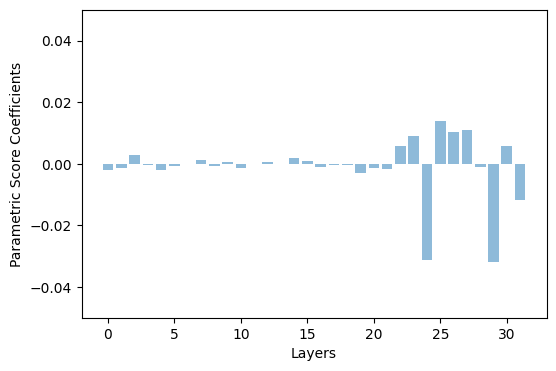

In [110]:
# parametric knowledge scores:
parametric_coefficients1 = datapoint1['parametric_scores']
parametric_coefficients1 = np.array([parametric_coefficients1.get(f'l{i}') for i in range(32)])

parametric_coefficients2 = datapoint2['parametric_scores']
parametric_coefficients2 = np.array([parametric_coefficients2.get(f'l{i}') for i in range(32)])

fig,ax = plt.subplots(figsize=(6,4), dpi = 100)
ax.bar(
    range(len(parametric_coefficients)), parametric_coefficients1 - parametric_coefficients2, alpha = 0.5
)
ax.set_ylabel('Parametric Score Coefficients')
ax.set_xlabel('Layers')
ax.set_ylim(-0.05, 0.05)

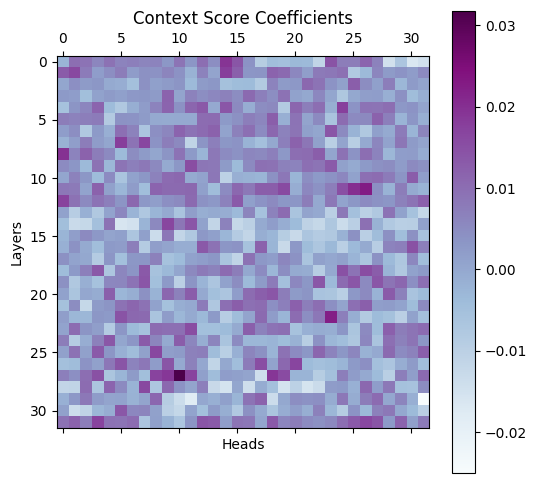

In [111]:
context_coefficients = np.zeros((32,32))
for layer in range(32):
    for head in range(32):
        context_coefficients[layer, head] = datapoint1['context_scores'].get(f'l{layer}h{head}', 0.0) - datapoint2['context_scores'].get(f'l{layer}h{head}', 0.0)
fig,ax = plt.subplots(figsize=(6,6), dpi = 100)
pos = ax.matshow(context_coefficients, cmap='BuPu')
ax.set_ylabel('Layers')
ax.set_xlabel('Heads')
ax.set_title(f'Context Score Coefficients')
fig.colorbar(pos, ax=ax)




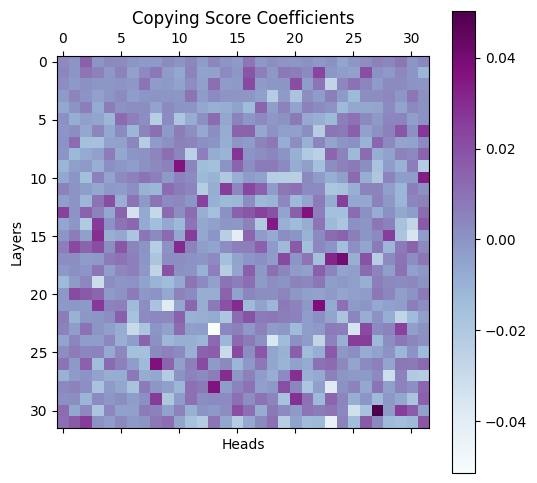

In [112]:
copying_coefficients = np.zeros((32,32))
for layer in range(32):
    for head in range(32):
        copying_coefficients[layer, head] = context_coefficients[layer, head] = datapoint1['copying_scores'].get(f'l{layer}h{head}', 0.0) - datapoint2['copying_scores'].get(f'l{layer}h{head}', 0.0)
fig,ax = plt.subplots(figsize=(6,6), dpi = 100)
pos = ax.matshow(copying_coefficients, cmap='BuPu')
ax.set_ylabel('Layers')
ax.set_xlabel('Heads')
ax.set_title(f'Copying Score Coefficients')
fig.colorbar(pos, ax=ax)

In [74]:
result_df

,title,author,year,paper_id,location,chunk_id,date,context,ecosystem,name,measurement,value,units,judgement,processed_value
0,agricultural freshwater pond supports diverse ...,chopyk et al.,2018.0,0,"central Maryland, United States",18,2016-10-01,Ten-liter water samples were collected in Octo...,pond,temperate freshwater agricultural pond,max_depth,3.35,m,valid,3.35
1,agricultural freshwater pond supports diverse ...,chopyk et al.,2018.0,0,None,40,October,<table>\n <tr>\n <th>Water property</th>\n...,pond,Agricultural pond,ph,7.70,NaN,valid,7.70
2,agricultural freshwater pond supports diverse ...,chopyk et al.,2018.0,0,"central Maryland, United States",18,2016-12-01,Ten-liter water samples were collected in Octo...,pond,temperate freshwater agricultural pond,surface_area,0.26,ha,valid,2600.00
3,agricultural freshwater pond supports diverse ...,chopyk et al.,2018.0,0,"central Maryland, United States",18,2016-10-01,Ten-liter water samples were collected in Octo...,pond,temperate freshwater agricultural pond,surface_area,0.26,ha,valid,2600.00
4,agricultural freshwater pond supports diverse ...,chopyk et al.,2018.0,0,None,40,November,<table>\n <tr>\n <th>Water property</th>\n...,pond,Agricultural pond,ph,7.56,NaN,valid,7.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4371,zooplankton body size versus taxonomy in medit...,gilbert; juan diego; de vicente; inmaculada; j...,2017.0,127,None,28,None,<table>\n <tr>\n <th>Variable</th>\n <t...,wetland,Ardal,chla,7.20,µg/L,valid,7.20
4372,zooplankton body size versus taxonomy in medit...,gilbert; juan diego; de vicente; inmaculada; j...,2017.0,127,None,28,None,<table>\n <tr>\n <th>Variable</th>\n <t...,wetland,Orcera,ph,8.10,NaN,valid,8.10
4373,zooplankton body size versus taxonomy in medit...,gilbert; juan diego; de vicente; inmaculada; j...,2017.0,127,None,28,None,<table>\n <tr>\n <th>Variable</th>\n <t...,wetland,Castillo,ph,8.30,NaN,valid,8.30
4374,zooplankton body size versus taxonomy in medit...,gilbert; juan diego; de vicente; inmaculada; j...,2017.0,127,None,28,None,<table>\n <tr>\n <th>Variable</th>\n <t...,wetland,Quinta Casillas,chla,8.80,µg/L,valid,8.80
